# Zalando Network Planning — Warehouse Inbound Forecast

In [247]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.1f}".format)

## 1. Load Data

In [248]:
hist = pd.read_csv(
    "data_input/202402_Data - Case Study - Analyst Network Planning_vShared - input_1_histrocial.csv",
    parse_dates=["date_order", "date_wh_receive"]
)

fc = pd.read_csv(
    "data_input/202402_Data - Case Study - Analyst Network Planning_vShared - input_2_sales_fc.csv",
    parse_dates=["date_order"]
)

print("Historical data:", hist.shape)
display(hist.head())

print("\nSales forecast:", fc.shape)
display(fc.head())

Historical data: (1763, 6)


,date_order,day_of_week_order,date_wh_receive,day_of_week_wh_receive,CW,items
0,2022-01-01,6,2022-01-01,6,52,18338
1,2022-01-01,6,2022-01-02,7,52,408
2,2022-01-01,6,2022-01-03,1,1,2551
3,2022-01-01,6,2022-01-04,2,1,11965
4,2022-01-01,6,2022-01-05,3,1,180



Sales forecast: (30, 3)


,date_order,day_of_week_order,Forecated_items
0,2022-06-01,3,80882
1,2022-06-02,4,58562
2,2022-06-03,5,55809
3,2022-06-04,6,48880
4,2022-06-05,7,49208


## 2. Data Quality Checks

### Checking Historical Data

In [249]:
### input_1: Shape and dtypes
print("=== input_1: Historical Data ===")
print(f"Shape: {hist.shape}")
print()
print(hist.dtypes)

=== input_1: Historical Data ===
Shape: (1763, 6)

date_order                datetime64[us]
day_of_week_order                  int64
date_wh_receive           datetime64[us]
day_of_week_wh_receive             int64
CW                                 int64
items                              int64
dtype: object


All data types are loaded in correct format.

In [250]:
### input_1: Missing values
print("=== input_1: Missing Values ===")
print(hist.isnull().sum())

=== input_1: Missing Values ===
date_order                0
day_of_week_order         0
date_wh_receive           0
day_of_week_wh_receive    0
CW                        0
items                     0
dtype: int64


We don't have any nulls in the dataset.

In [251]:
### input_1: Date range
print("=== input_1: Date Range ===")
print(f"date_order:      {hist['date_order'].min().date()} → {hist['date_order'].max().date()}")
print(f"date_wh_receive: {hist['date_wh_receive'].min().date()} → {hist['date_wh_receive'].max().date()}")
print(f"Unique order dates: {hist['date_order'].nunique()}")

=== input_1: Date Range ===
date_order:      2022-01-01 → 2022-05-31
date_wh_receive: 2022-01-01 → 2022-06-11
Unique order dates: 151


Order Dates range from Jan'22 till end of May'22. However, there is a *Spillover from May orders* into June receiving, which needs to be accounted for in June forecast.

In [252]:
### input_1: Negative or zero item counts
neg_hist = hist[hist["items"] <= 0]
print(f"=== input_1: Negative or Zero Items ===")
print(f"Rows with items <= 0: {len(neg_hist)}")
if len(neg_hist) > 0:
    display(neg_hist)

=== input_1: Negative or Zero Items ===
Rows with items <= 0: 0


We don't have any 0 or negative values in 'items' data.

In [253]:
### input_1: Duplicate rows
dupes_hist = hist.duplicated().sum()
print(f"=== input_1: Duplicate Rows ===")
print(f"Duplicate rows: {dupes_hist}")

=== input_1: Duplicate Rows ===
Duplicate rows: 0


No entire duplicate records found.

### Historicals Outlier Detection

In [254]:
### input_1: Outlier check on items (IQR method)
Q1 = hist["items"].quantile(0.25)
Q3 = hist["items"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers_hist = hist[hist["items"] > upper_bound].sort_values("items", ascending=False)
print(f"=== input_1: Outliers in Items (IQR method) ===")
print(f"Q1: {Q1:,.0f} | Q3: {Q3:,.0f} | IQR: {IQR:,.0f} | Upper bound: {upper_bound:,.0f}")
print(f"\nRows exceeding upper bound: {len(outliers_hist)}")
if len(outliers_hist) > 0:
    display(outliers_hist)

=== input_1: Outliers in Items (IQR method) ===
Q1: 19 | Q3: 5,423 | IQR: 5,404 | Upper bound: 13,529

Rows exceeding upper bound: 326


,date_order,day_of_week_order,date_wh_receive,day_of_week_wh_receive,CW,items
1731,2022-05-29,7,2022-05-29,7,21,27533000
1498,2022-05-08,7,2022-05-10,2,19,74843
277,2022-01-23,7,2022-01-25,2,4,66254
289,2022-01-24,1,2022-01-26,3,4,61991
300,2022-01-25,2,2022-01-27,4,4,60645
...,...,...,...,...,...,...
606,2022-02-20,7,2022-02-21,1,8,14287
1326,2022-04-24,7,2022-04-25,1,17,14277
1543,2022-05-12,4,2022-05-13,5,19,13942
1227,2022-04-16,6,2022-04-16,6,15,13732


**Limitation of IQR method here:**

The IQR method flags 326 rows (~18.5% of data) as outliers, which is far too many to be genuine anomalies. The issue is that `items` is inherently right-skewed by design:
- **Q1 = 19** — driven down by the many small trickle amounts at long lags (e.g. 3 items arriving 15 days after order)
- **Q3 = 5,423** — where the bulk of volume sits
- The resulting upper bound of 13,529 incorrectly flags legitimate high-volume records (e.g. same-day receipts of 50,000+ items)

IQR works well for symmetric distributions. Here, the skew is structural — a few rows carry large volumes at short lags, while many rows carry tiny volumes at long lags. A **magnitude gap check** is more appropriate: it looks for a disproportionate jump between the largest value and the rest, which is the actual signature of a data entry error.

In [255]:
### input_1: Outlier check on items (magnitude gap check)
sorted_items = hist["items"].sort_values(ascending=False).reset_index(drop=True)
gap_ratio = sorted_items / sorted_items.shift(-1)

print("=== input_1: Top 10 items values with gap ratio to next ===")
top10 = pd.DataFrame({
    "items": sorted_items[:10],
    "gap_ratio_to_next": gap_ratio[:10].round(1)
})
display(top10)

# Flag rows where gap ratio exceeds 10x
threshold = 10
anomalies = hist[hist["items"] >= sorted_items[gap_ratio[gap_ratio > threshold].index[0]]] \
    if (gap_ratio > threshold).any() else pd.DataFrame()

print(f"\nRows with a >10x gap to the next highest value: {len(anomalies)}")
if len(anomalies) > 0:
    display(anomalies)

=== input_1: Top 10 items values with gap ratio to next ===


,items,gap_ratio_to_next
0,27533000,367.9
1,74843,1.1
2,66254,1.1
3,61991,1.0
4,60645,1.1
5,54253,1.1
6,50788,1.0
7,50287,1.0
8,50091,1.1
9,47516,1.1



Rows with a >10x gap to the next highest value: 1


,date_order,day_of_week_order,date_wh_receive,day_of_week_wh_receive,CW,items
1731,2022-05-29,7,2022-05-29,7,21,27533000


There is exactly one genuine anomaly. Everything else is legitimate high-volume data.

The May 29 record is a data entry error — the 367.9x gap is not a business pattern, it's a magnitude mistake. A realistic same-day receipt for a large retailer might be 50,000–75,000 items, which is exactly what the surrounding rows show. 27,533,000 is physically implausible.

**Outlier Handling: Impute Median**  
We want to preserve the realistic shape of May 29's lag distribution — specifically that lag=0 carries the largest share, consistent with every other order date. Imputing a plausible value restores that shape.

The most contextually appropriate choice is the median lag=0 items value for Sunday orders (day_of_week = 7) from the rest of the historical data. This accounts for:

- Same-day receipt behaviour specifically (lag=0)
- Day-of-week pattern (May 29 is a Sunday)


In [256]:
### input_1: Impute May 29 anomaly with median lag=0 Sunday value
hist["lag"] = (hist["date_wh_receive"] - hist["date_order"]).dt.days

sunday_lag0_median = hist[
    (hist["day_of_week_order"] == 7) &
    (hist["lag"] == 0) &
    (hist["items"] < 27533000)  # exclude the anomaly itself
]["items"].median()

print(f"Median lag=0 items for Sunday orders: {sunday_lag0_median:,.0f}")

# Apply imputation
hist.loc[1731, "items"] = sunday_lag0_median
print(f"\nImputed row 1731:")
display(hist.loc[[1731]])

Median lag=0 items for Sunday orders: 32,161

Imputed row 1731:


,date_order,day_of_week_order,date_wh_receive,day_of_week_wh_receive,CW,items,lag
1731,2022-05-29,7,2022-05-29,7,21,32161,0


In [257]:
### Total items per order date
total_per_order = hist.groupby("date_order")["items"].sum()
total_per_order.head()

date_order
2022-01-01    33614
2022-01-02    52529
2022-01-03    90112
2022-01-04    83831
2022-01-05    66818
Name: items, dtype: int64

In [258]:
# Calculate share sums per order to whs receiving date
share_sums = (
    hist.groupby(["date_order", "date_wh_receive"])["items"].sum()
    .div(total_per_order, level="date_order")
    
)
share_sums.head()

date_order  date_wh_receive
2022-01-01  2022-01-01        0.5
            2022-01-02        0.0
            2022-01-03        0.1
            2022-01-04        0.4
            2022-01-05        0.0
Name: items, dtype: float64

In [259]:
# Aggregate share sums by order date to check total shares sum to 1
share_sums = share_sums.groupby("date_order").sum()
share_sums.head()

date_order
2022-01-01   1.0
2022-01-02   1.0
2022-01-03   1.0
2022-01-04   1.0
2022-01-05   1.0
Name: items, dtype: float64

In [260]:
print("=== input_1: Item Share Sum per Order Date ===")
print(share_sums.describe().to_frame("share_sum"))
incomplete = share_sums[share_sums < 0.99]
print(f"\nOrder dates with share sum < 99%: {len(incomplete)}")
if len(incomplete) > 0:
    display(incomplete)

=== input_1: Item Share Sum per Order Date ===
       share_sum
count      151.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0

Order dates with share sum < 99%: 0


Every single order date has a perfect share sum of 1.0 — no missing receipts, no data gaps.

### Data Quality Summary — input_1 (Historical Data)

| Check | Result |
|---|---|
| Shape | 1,763 rows × 6 columns |
| Unique order dates | 151 (Jan 1 – May 31, 2022) |
| Missing values | None |
| Duplicate rows | None |
| Negative / zero items | None |
| Date range | Orders: Jan–May 2022; WH receipts extend to Jun 11, 2022 |
| Share sums per order date | All exactly 1.0 — no data gaps or losses |
| Data types | Dates as `datetime64`, numeric columns as `int64` |
| Outliers | 1 anomaly detected on May 29 (items = 27,533,000; 368x the next highest value). Identified as a data entry error via magnitude gap check. Imputed with the median lag=0 Sunday value (32,161) to preserve the realistic shape of the lag distribution. |

**Overall:** input_1 is clean and complete after outlier treatment. Late-May orders spill into early June warehouse receipts and will need to be accounted for in the forecast.

### Checking Sales Forecast Data

In [261]:
fc.head()

,date_order,day_of_week_order,Forecated_items
0,2022-06-01,3,80882
1,2022-06-02,4,58562
2,2022-06-03,5,55809
3,2022-06-04,6,48880
4,2022-06-05,7,49208


In [262]:
### input_2: Shape, dtypes, missing values
print("=== input_2: Sales Forecast ===")
print(f"Shape: {fc.shape}")
print()
print(fc.dtypes)
print()
print("Missing values:")
print(fc.isnull().sum())

=== input_2: Sales Forecast ===
Shape: (30, 3)

date_order           datetime64[us]
day_of_week_order             int64
Forecated_items               int64
dtype: object

Missing values:
date_order           0
day_of_week_order    0
Forecated_items      0
dtype: int64


Data covers 30 days, no null values.

In [263]:
### input_2: Date range and gaps
print("=== input_2: Date Range ===")
print(f"Range: {fc['date_order'].min().date()} → {fc['date_order'].max().date()}")
print(f"Unique dates: {fc['date_order'].nunique()} (expected 30 for June)")

expected_dates = pd.date_range("2022-06-01", "2022-06-30")
missing_dates = expected_dates.difference(fc["date_order"])
print(f"Missing dates: {list(missing_dates.date) if len(missing_dates) > 0 else 'None'}")

=== input_2: Date Range ===
Range: 2022-06-01 → 2022-06-30
Unique dates: 30 (expected 30 for June)
Missing dates: None


Date range covers 30 days as expected for June.

In [264]:
### input_2: Negative or zero forecasted items
neg_fc = fc[fc["Forecated_items"] <= 0]
print(f"=== input_2: Negative or Zero Forecasted Items ===")
print(f"Rows with Forecated_items <= 0: {len(neg_fc)}")
if len(neg_fc) > 0:
    display(neg_fc)

=== input_2: Negative or Zero Forecasted Items ===
Rows with Forecated_items <= 0: 0


No negative or 0 sales fcst dates.

In [265]:
### input_2: Outlier check on forecasted items (IQR method)
Q1_fc = fc["Forecated_items"].quantile(0.25)
Q3_fc = fc["Forecated_items"].quantile(0.75)
IQR_fc = Q3_fc - Q1_fc
upper_bound_fc = Q3_fc + 1.5 * IQR_fc

outliers_fc = fc[fc["Forecated_items"] > upper_bound_fc].sort_values("Forecated_items", ascending=False)
print(f"=== input_2: Outliers in Forecated_items (IQR method) ===")
print(f"Q1: {Q1_fc:,.0f} | Q3: {Q3_fc:,.0f} | IQR: {IQR_fc:,.0f} | Upper bound: {upper_bound_fc:,.0f}")
print(f"\nRows exceeding upper bound: {len(outliers_fc)}")
if len(outliers_fc) > 0:
    display(outliers_fc)

=== input_2: Outliers in Forecated_items (IQR method) ===
Q1: 63,920 | Q3: 95,487 | IQR: 31,567 | Upper bound: 142,837

Rows exceeding upper bound: 1


,date_order,day_of_week_order,Forecated_items
27,2022-06-28,2,183785


We have one outlier in the forecast on 28th June, having items forecast as 183785, which is greater than upper bound value of 142,837.

183,785 is ~1.3x the IQR upper bound (142,837) — not comparable to the 368x gap we saw in input_1. There's no evidence of a data entry error. The gap ratio to the next highest value would be small.

In [266]:
### input_2: Day-of-week distribution
print("=== input_2: Day-of-Week Distribution ===")
dow_fc = fc["day_of_week_order"].value_counts().sort_index()
print(dow_fc.to_frame("count"))
print(f"\nDays of week present: {sorted(fc['day_of_week_order'].unique())}")

=== input_2: Day-of-Week Distribution ===
                   count
day_of_week_order       
1                      4
2                      4
3                      5
4                      5
5                      4
6                      4
7                      4

Days of week present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


 The forecast covers every day of the week, including weekends. This means when we apply the lag distribution, we need it to work for all weekday types, not just Mon–Fri.

In [267]:
### Cross-dataset: day_of_week encoding consistency
print("=== Cross-dataset: Day-of-Week Encoding ===")
print("input_1 day_of_week_order values:", sorted(hist["day_of_week_order"].unique()))
print("input_2 day_of_week_order values:", sorted(fc["day_of_week_order"].unique()))

# Verify encoding is consistent: check a known date against its day_of_week value
sample = hist[["date_order", "day_of_week_order"]].drop_duplicates().head(7)
sample["pandas_dow"] = sample["date_order"].dt.dayofweek + 1  # Monday=1
sample["match"] = sample["day_of_week_order"] == sample["pandas_dow"]
print()
display(sample)

=== Cross-dataset: Day-of-Week Encoding ===
input_1 day_of_week_order values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
input_2 day_of_week_order values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]



,date_order,day_of_week_order,pandas_dow,match
0,2022-01-01,6,6,True
12,2022-01-02,7,7,True
23,2022-01-03,1,1,True
33,2022-01-04,2,2,True
46,2022-01-05,3,3,True
58,2022-01-06,4,4,True
71,2022-01-07,5,5,True


- Verified that both historical data and forecast are aligned with same day of week encoding. If one used 0–6 and the other 1–7, they'd be misaligned by one day — a silent but serious bug.
- Encoding is *1 = Monday through 7 = Sunday* in both datasets.

In [268]:
### Cross-dataset: weekday coverage
print("=== Cross-dataset: Weekday Coverage ===")
hist_dow = set(hist["day_of_week_order"].unique())
fc_dow = set(fc["day_of_week_order"].unique())
missing_in_hist = fc_dow - hist_dow
print(f"Days in forecast not in historical: {missing_in_hist if missing_in_hist else 'None — full coverage'}")

=== Cross-dataset: Weekday Coverage ===
Days in forecast not in historical: None — full coverage


Each day of week in fcst has a day in historical, from where we can read pattern.

### Data Quality Summary — input_2 (Sales Forecast)

| Check | Result |
|---|---|
| Shape | 30 rows × 3 columns |
| Date range | Jun 1 – Jun 30, 2022 — all 30 days present, no gaps |
| Missing values | None |
| Negative / zero forecasted items | None |
| Day-of-week coverage | All 7 days represented (4–5 occurrences each) |
| Day-of-week encoding | Consistent with input_1 — 1 = Monday, 7 = Sunday |
| Weekday coverage vs. historical | Full — every forecast weekday has historical data to draw from |
| Outliers | 1 high value flagged by IQR on Jun 28 (183,785 items; IQR upper bound: 142,837). Assessed as plausible — magnitude is only 1.3x the upper bound, no evidence of a data entry error. As a business-provided forecast input, it is retained as-is. May represent a planned promotion or end-of-month sales event. |

**Overall:** input_2 is clean and complete. No remediation required before modelling. The Jun 28 high value is noted and will manifest as a receipt spike around Jun 29–30 in the final output.

## 3. Data Exploration

### 3.1 Orders by Month (Trendline)

In [269]:
#=== Cross-dataset: Monthly items aggregation ===
# Monthly aggregate from historical data
hist["month"] = hist["date_order"].dt.to_period("M")
monthly_orders = hist.groupby("month")["items"].sum().reset_index()
monthly_orders["month_str"] = monthly_orders["month"].astype(str)

# June forecast total
june_total = fc["Forecated_items"].sum()
june_row = {"month": pd.Period("2022-06", freq="M"), "month_str": "2022-06", "items": june_total}
monthly_orders = pd.concat([monthly_orders, pd.DataFrame([june_row])], ignore_index=True)

In [270]:
monthly_orders

,month,items,month_str
0,2022-01,2340563,2022-01
1,2022-02,1712131,2022-02
2,2022-03,1918096,2022-03
3,2022-04,2154274,2022-04
4,2022-05,2240077,2022-05
5,2022-06,2433610,2022-06


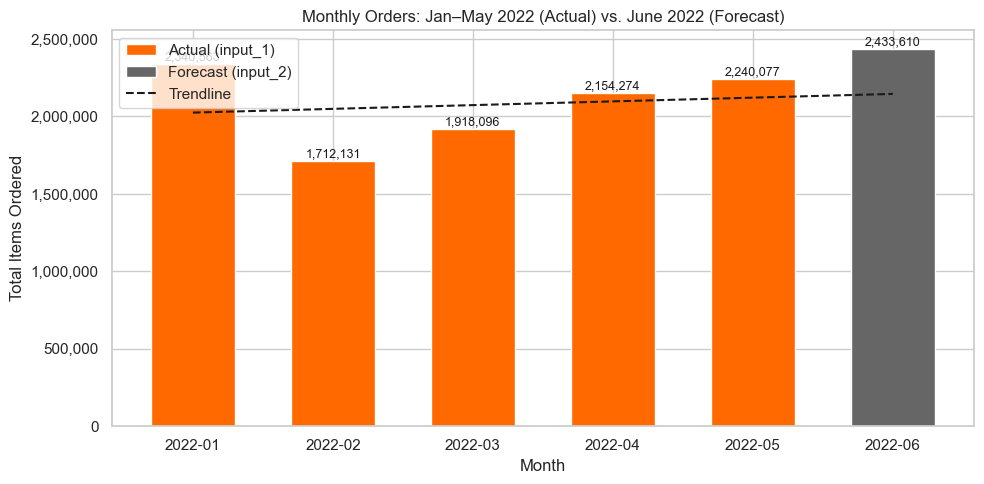

In [271]:
# Plotting the monthly totals with a trendline (historical months + June forecast)
# Trendline through historical months only (exclude June forecast)
hist_only = monthly_orders[monthly_orders["month_str"] != "2022-06"].copy()
x = np.arange(len(hist_only))
slope, intercept, _, _, _ = linregress(x, hist_only["items"])
trendline_y = slope * np.arange(len(monthly_orders)) + intercept

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#FF6900" if m != "2022-06" else "#666666" for m in monthly_orders["month_str"]]
bars = ax.bar(monthly_orders["month_str"], monthly_orders["items"], color=colors, width=0.6)

ax.plot(monthly_orders["month_str"], trendline_y, color="#1A1A1A", linewidth=1.5,
        linestyle="--", label="Trendline (historical)")

# Labels on bars
for bar, val in zip(bars, monthly_orders["items"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=9, color="#1A1A1A")

ax.set_xlabel("Month")
ax.set_ylabel("Total Items Ordered")
ax.set_title("Monthly Orders: Jan–May 2022 (Actual) vs. June 2022 (Forecast)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#FF6900", label="Actual (input_1)"),
    Patch(facecolor="#666666", label="Forecast (input_2)"),
    plt.Line2D([0], [0], color="#1A1A1A", linestyle="--", label="Trendline")
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

**Observations:**
- Overall trend is **upward** across Jan–May 2022, with a seasonal dip in February (shortest month, lowest demand).
- Consistent month-on-month recovery from March onwards: +12% (Mar), +12% (Apr), +4% (May).
- June forecast (2.43M) sits **above the trendline** and ~8.6% above May — consistent with the growth trajectory and likely reflects seasonal demand acceleration heading into summer.
- The trendline slope is modestly understated due to the February trough pulling it down; the Apr–May momentum is stronger than the line suggests.

### 3.2 Orders vs. Receivings by Calendar Week

In [272]:
# Orders by CW — derived inline from date_order
orders_by_cw = (
    hist.groupby(hist["date_order"].dt.isocalendar().week.astype(int))["items"]
    .sum().reset_index()
)
orders_by_cw.columns = ["CW", "ordered_items"]
orders_by_cw.head()

,CW,ordered_items
0,1,471070
1,2,532554
2,3,619536
3,4,583896
4,5,460164


In [273]:
# Receivings by CW — use existing CW column directly (based on date_wh_receive)
recv_by_cw = hist.groupby("CW")["items"].sum().reset_index()
recv_by_cw.columns = ["CW", "received_items"]
recv_by_cw.head()

,CW,received_items
0,1,450050
1,2,473232
2,3,596176
3,4,650974
4,5,455086


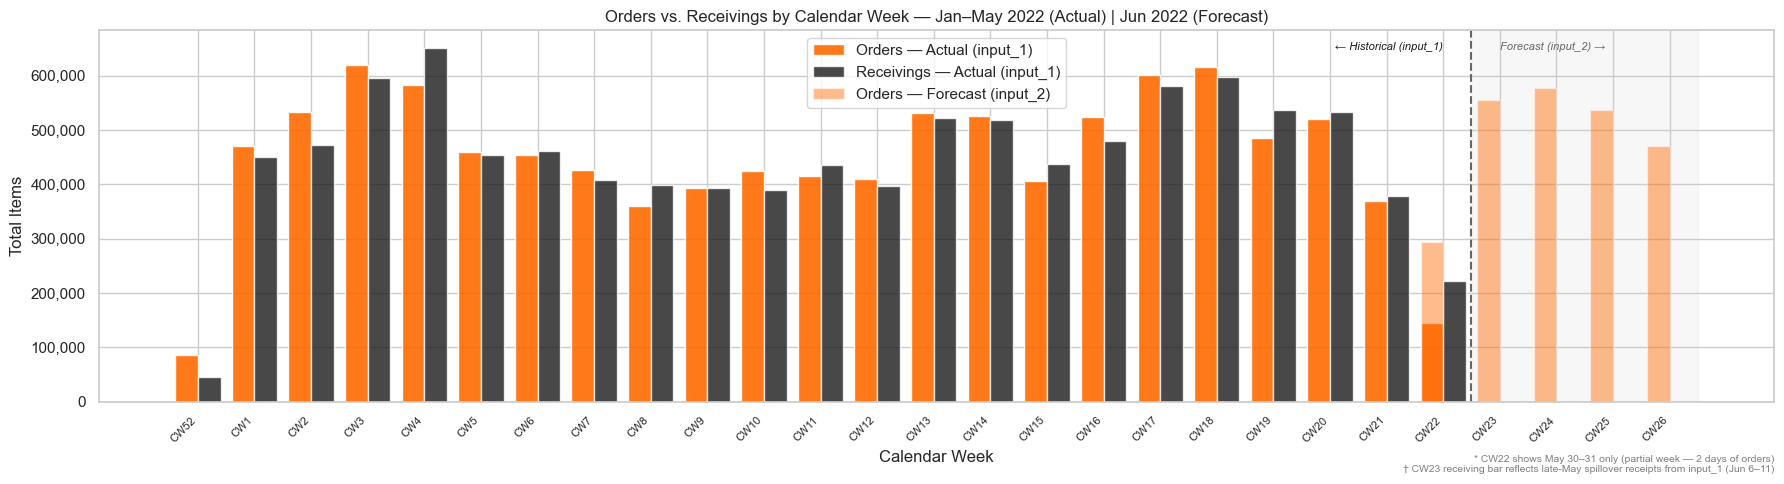

In [274]:
# Build historical CW dataframe
cw_df = orders_by_cw.merge(recv_by_cw, on="CW", how="outer").fillna(0)
cw_df = pd.concat([
    cw_df[cw_df["CW"] == 52],
    cw_df[cw_df["CW"] != 52].sort_values("CW")
]).reset_index(drop=True)

# June forecast by CW (input_2)
fc_cw = (
    fc.assign(cw=fc["date_order"].dt.isocalendar().week.astype(int))
    .groupby("cw")["Forecated_items"].sum()
    .reset_index()
    .rename(columns={"cw": "CW", "Forecated_items": "forecast_items"})
)

# Map forecast_items onto existing CW rows (CW22 and CW23 already in cw_df from input_1)
cw_df["forecast_items"] = cw_df["CW"].map(fc_cw.set_index("CW")["forecast_items"]).fillna(0)

# Append only CWs not already in cw_df (CW24–26)
new_fc_cws = fc_cw[~fc_cw["CW"].isin(cw_df["CW"])].copy()
new_fc_cws["ordered_items"] = 0
new_fc_cws["received_items"] = 0
cw_full = pd.concat([
    cw_df,
    new_fc_cws[["CW", "ordered_items", "received_items", "forecast_items"]].sort_values("CW")
], ignore_index=True)

# Forecast zone starts after the last CW with actual input_1 orders (CW22)
last_hist_orders_idx = cw_full[cw_full["ordered_items"] > 0].index.max()
forecast_start_x = last_hist_orders_idx + 0.5

# Plot
x = np.arange(len(cw_full))
width = 0.4

fig, ax = plt.subplots(figsize=(18, 5))

ax.bar(x - width/2, cw_full["ordered_items"], width,
       label="Orders — Actual (input_1)", color="#FF6900", alpha=0.9)
ax.bar(x + width/2, cw_full["received_items"], width,
       label="Receivings — Actual (input_1)", color="#1A1A1A", alpha=0.8)

fc_mask = cw_full["forecast_items"] > 0
ax.bar(x[fc_mask] - width/2, cw_full.loc[fc_mask, "forecast_items"], width,
       label="Orders — Forecast (input_2)", color="#FF6900", alpha=0.45)

# Shaded forecast region
ax.axvspan(forecast_start_x, len(cw_full) - 0.5, alpha=0.07, color="#999999", zorder=0)

# Vertical dividing line
ax.axvline(x=forecast_start_x, color="#666666", linestyle="--", linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels([f"CW{int(cw)}" for cw in cw_full["CW"]], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("Calendar Week")
ax.set_ylabel("Total Items")
ax.set_title("Orders vs. Receivings by Calendar Week — Jan–May 2022 (Actual) | Jun 2022 (Forecast)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))

ymax = ax.get_ylim()[1]
ax.text(forecast_start_x - 0.5, ymax * 0.97,
        "← Historical (input_1)", ha="right", va="top", fontsize=8, color="#1A1A1A", style="italic")
ax.text(forecast_start_x + 0.5, ymax * 0.97,
        "Forecast (input_2) →", ha="left", va="top", fontsize=8, color="#666666", style="italic")

ax.legend()

ax.annotate(
    "* CW22 shows May 30–31 only (partial week — 2 days of orders)\n"
    "† CW23 receiving bar reflects late-May spillover receipts from input_1 (Jun 6–11)",
    xy=(1, 0), xycoords="axes fraction",
    ha="right", va="bottom", fontsize=7.5, color="grey",
    xytext=(0, -52), textcoords="offset points"
)

plt.tight_layout()
plt.show()

**Observations:**
- Orders and receivings track closely for most historical weeks — confirming the lag is short and concentrated within the same or next week.
- **CW3–CW4 spike:** likely a post-Christmas/January sales effect; both orders and receivings peak here.
- **CW7–CW12 dip:** aligns with the February trough seen in the monthly chart — seasonal low demand.
- **CW13+ recovery:** steady growth from April onwards, consistent with the monthly upward trend.
- **CW22 partial week:** order bar is artificially small (~140k) because CW22 only captures May 30–31 (2 days). Receivings remain higher as prior weeks' orders continue to arrive.
- **CW23 spillover bar:** receiving bar reflects late-May orders arriving in Jun 6–11 (from input_1). The accompanying lighter orange bar is the Jun 6–12 forecast orders — both visible on the same CW23 position.
- **Jun forecast (CW23–26, shaded):** forecast order volumes are higher than historical weeks at comparable seasonal positions, consistent with the ~8.6% June demand uplift. No forecast receiving bars are shown — the June receipt forecast is the subject of section 4.
- **CW26 shorter bar:** CW26 covers only Jun 27–30 (4 days, partial week), so the raw total is naturally lower. This is not a demand drop — daily average orders for CW26 are in line with the rest of June.

### 3.3 Orders vs. Receivings by Day of Week

In [275]:
# Average daily orders by day of week
orders_dow = (
    hist.groupby(["date_order", "day_of_week_order"])["items"]
    .sum()
    .reset_index()
    .groupby("day_of_week_order")["items"]
    .mean()
    .reset_index()
)
orders_dow.columns = ["day_of_week", "avg_ordered"]
orders_dow.head()

,day_of_week,avg_ordered
0,1,"72,568.0"
1,2,"78,297.7"
2,3,"71,518.3"
3,4,"71,868.9"
4,5,"59,583.0"


In [276]:
# Average daily receivings by day of week
recv_dow = (
    hist.groupby(["date_wh_receive", "day_of_week_wh_receive"])["items"]
    .sum()
    .reset_index()
    .groupby("day_of_week_wh_receive")["items"]
    .mean()
    .reset_index()
)
recv_dow.columns = ["day_of_week", "avg_received"]
recv_dow.head()

,day_of_week,avg_received
0,1,"72,226.4"
1,2,"86,274.5"
2,3,"77,702.3"
3,4,"69,549.4"
4,5,"62,856.4"


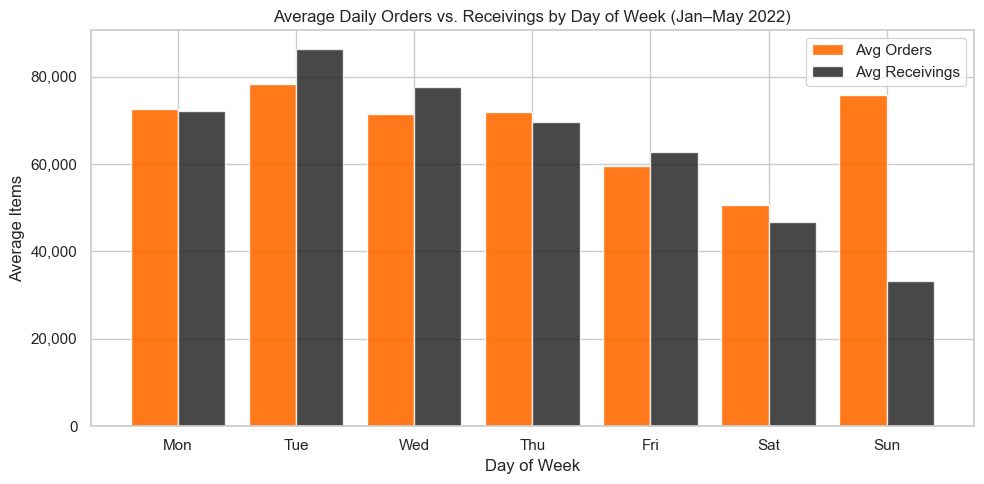

In [277]:
# Plotting average daily orders vs. receivings by day of week 
# Merge
dow_df = orders_dow.merge(recv_dow, on="day_of_week")
day_labels = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
dow_df["day_label"] = dow_df["day_of_week"].map(day_labels)

# Plot
x = np.arange(len(dow_df))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, dow_df["avg_ordered"], width, label="Avg Orders", color="#FF6900", alpha=0.9)
ax.bar(x + width/2, dow_df["avg_received"], width, label="Avg Receivings", color="#1A1A1A", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(dow_df["day_label"])
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Items")
ax.set_title("Average Daily Orders vs. Receivings by Day of Week (Jan–May 2022)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax.legend()

plt.tight_layout()
plt.show()

**Observations:**
- **Weekdays (Mon–Fri):** orders and receivings are broadly aligned (~60k–80k). Receivings meet or slightly exceed orders on most weekdays due to spillover from previous days arriving throughout the week.
- **Saturday:** both orders and receivings drop — expected weekend demand and operational slowdown.
- **Sunday:** orders remain high (~76k, comparable to weekdays) but receivings drop sharply to ~33k — Sunday orders are largely not processed same-day, spilling into Monday/Tuesday. Likely reflects reduced warehouse operations on Sundays.
- **Modelling implication:** day-of-week segmentation for the lag distribution is warranted. Sunday in particular has a distinctly different lag profile — a single overall distribution would underestimate the lag for Sunday orders.

In [278]:
# Compute item-weighted share per (order date, lag)
total_per_order = hist.groupby("date_order")["items"].sum()
hist["share"] = hist["items"] / hist["date_order"].map(total_per_order)
hist.head()

,date_order,day_of_week_order,date_wh_receive,day_of_week_wh_receive,CW,items,lag,month,share
0,2022-01-01,6,2022-01-01,6,52,18338,0,2022-01,0.5
1,2022-01-01,6,2022-01-02,7,52,408,1,2022-01,0.0
2,2022-01-01,6,2022-01-03,1,1,2551,2,2022-01,0.1
3,2022-01-01,6,2022-01-04,2,1,11965,3,2022-01,0.4
4,2022-01-01,6,2022-01-05,3,1,180,4,2022-01,0.0


In [279]:
# Average share by (day_of_week_order, lag) — cap lag at 14 days (covers 99%+ of item volume)
lag_dow = (
    hist[hist["lag"] <= 14]
    .groupby(["day_of_week_order", "lag"])["share"]
    .mean()
    .reset_index()
)
lag_dow.head()

,day_of_week_order,lag,share
0,1,0,0.4
1,1,1,0.2
2,1,2,0.3
3,1,3,0.0
4,1,4,0.0


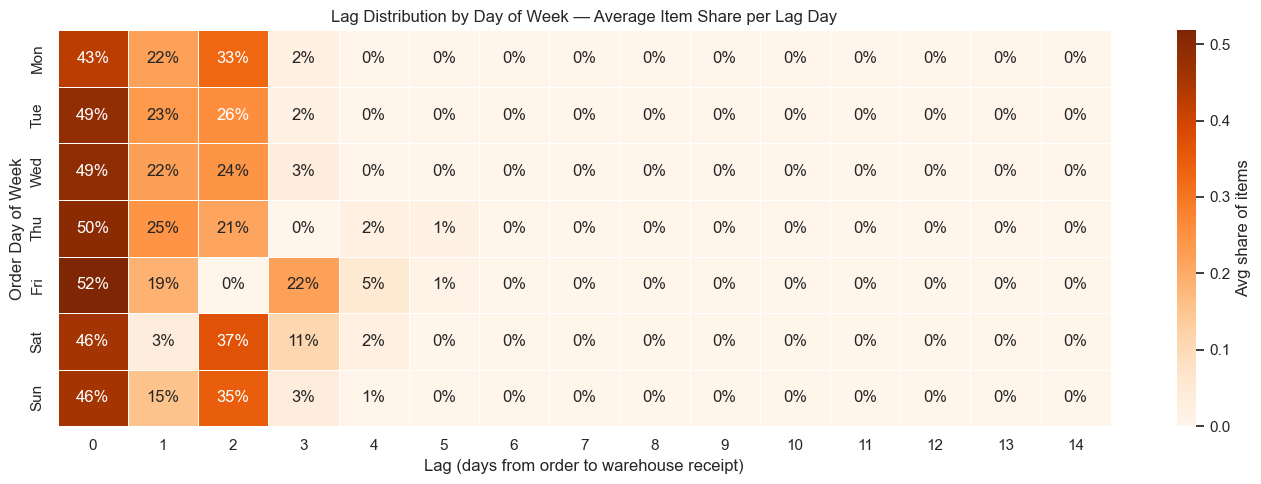

In [280]:
# Plotting lag distribution by day of week as a heatmap — average item share per lag day
# Pivot to matrix: rows = day of week, columns = lag
heatmap_data = lag_dow.pivot(index="day_of_week_order", columns="lag", values="share").fillna(0)
heatmap_data.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0%",
    cmap="Oranges",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Avg share of items"}
)
ax.set_xlabel("Lag (days from order to warehouse receipt)")
ax.set_ylabel("Order Day of Week")
ax.set_title("Lag Distribution by Day of Week — Average Item Share per Lag Day")
plt.tight_layout()
plt.show()

**Observations:**
- Lag 0, 1, and 2 dominate across all days of the week — together accounting for ~95%+ of item arrivals. Beyond lag 3 shares are negligible.
- **Mon–Thu** show broadly similar profiles (lag 0: ~43–50%, lag 1: ~22–25%, lag 2: ~21–33%) — weekday warehouse processing is consistent.
- **Friday** has a unique profile: lag 2 drops to 0% with a spike at lag 3 (22%). Friday orders skip Saturday warehouse processing and arrive Monday — a clear weekend effect.
- **Saturday** has very low lag 1 (3%) and peaks at lag 2 (37%) — most Saturday orders arrive Monday, with further spillover into Tuesday (lag 3: 11%).
- **Sunday** peaks at lag 2 (35%) with moderate lag 1 (15%) — consistent with reduced Sunday warehouse operations seen in Chart 1.
- **Modelling decision:** day-of-week segmentation is clearly justified. Fri, Sat, and Sun have distinctly different lag profiles from weekdays and must be modelled separately.

### 3.4 Outliers in Historical Receiving Data

In [281]:
# Daily receiving totals
daily_recv = (
    hist.groupby("date_wh_receive")["items"]
    .sum()
    .reset_index()
    .rename(columns={"items": "daily_received"})
)

# --- Check 1: Outliers in daily receiving totals (magnitude gap check) ---
sorted_recv = daily_recv["daily_received"].sort_values(ascending=False).reset_index(drop=True)
gap_ratio = sorted_recv / sorted_recv.shift(-1)

print("=== Daily Receiving Totals: Top 10 with Gap Ratio ===")
display(pd.DataFrame({
    "daily_received": sorted_recv[:10],
    "gap_ratio_to_next": gap_ratio[:10].round(1)
}))

=== Daily Receiving Totals: Top 10 with Gap Ratio ===


,daily_received,gap_ratio_to_next
0,168671,1.2
1,142391,1.0
2,139776,1.0
3,133616,1.1
4,124334,1.1
5,110289,1.0
6,108842,1.0
7,108804,1.0
8,108270,1.0
9,105407,1.0


In [282]:
anomalies = daily_recv[daily_recv["daily_received"] >= sorted_recv[gap_ratio[gap_ratio > 10].index[0]]]     if (gap_ratio > 10).any() else pd.DataFrame()
print(f"Days with >10x gap to next highest: {len(anomalies)}")
if len(anomalies) > 0:
    display(anomalies)

Days with >10x gap to next highest: 0


In [283]:

# --- Check 2: Zero-receiving days ---
all_recv_dates = pd.date_range(hist["date_wh_receive"].min(), hist["date_wh_receive"].max())
zero_recv_days = all_recv_dates.difference(daily_recv["date_wh_receive"])
print(f"=== Zero-Receiving Days ===")
print(f"Days with no warehouse receipts: {len(zero_recv_days)}")
if len(zero_recv_days) > 0:
    for d in zero_recv_days:
        print(f"  {d.date()} ({d.day_name()})")

=== Zero-Receiving Days ===
Days with no warehouse receipts: 0


**Observations:**
- No anomalous days in daily receiving totals — magnitude gap check found no value exceeding 10x the next highest.
- No zero-receiving days across the entire Jan–May 2022 period — the warehouse operated every calendar day without any closures or gaps.
- Combined with the row-level outlier checks in section 2 (one anomaly on May 29, already imputed), the receiving data is clean at both the row and daily aggregate level.

### 3.5 Lag Distribution Analysis

In [284]:
### Lag distribution — item-weighted percentiles
total_per_order = hist.groupby("date_order")["items"].sum()
hist["share"] = hist["items"] / hist["date_order"].map(total_per_order)
hist.head()

,date_order,day_of_week_order,date_wh_receive,day_of_week_wh_receive,CW,items,lag,month,share
0,2022-01-01,6,2022-01-01,6,52,18338,0,2022-01,0.5
1,2022-01-01,6,2022-01-02,7,52,408,1,2022-01,0.0
2,2022-01-01,6,2022-01-03,1,1,2551,2,2022-01,0.1
3,2022-01-01,6,2022-01-04,2,1,11965,3,2022-01,0.4
4,2022-01-01,6,2022-01-05,3,1,180,4,2022-01,0.0


In [285]:
# Pivot first so missing lags are filled with 0 before averaging
lag_pivot = hist.pivot_table(
    index="date_order", columns="lag", values="share", aggfunc="sum", fill_value=0
)

# Average across all order dates — every date now contributes 0 for lags it has no entries
lag_cdf = (
    lag_pivot.mean()
    .sort_index()
    .cumsum()
    .reset_index()
    .rename(columns={0: "cumulative_share", "lag": "lag"})
)
lag_cdf.columns = ["lag", "cumulative_share"]
lag_cdf.head()

,lag,cumulative_share
0,0,0.5
1,1,0.7
2,2,0.9
3,3,1.0
4,4,1.0


In [286]:
print("=== Lag Distribution: Item-Weighted Percentiles ===")
for pct in [90, 95, 99]:
    lag_cutoff = lag_cdf[lag_cdf["cumulative_share"] >= pct/100]["lag"].iloc[0]
    print(f"  {pct}th percentile: lag ≤ {lag_cutoff} days")

print(f"Cumulative share by lag day:")
display(lag_cdf[lag_cdf["lag"] <= 10].set_index("lag").style.format("{:.1%}"))

=== Lag Distribution: Item-Weighted Percentiles ===
  90th percentile: lag ≤ 2 days
  95th percentile: lag ≤ 3 days
  99th percentile: lag ≤ 4 days
Cumulative share by lag day:


,cumulative_share
lag,
0,47.6%
1,66.1%
2,91.3%
3,97.6%
4,99.1%
5,99.6%
6,99.7%
7,99.9%
8,99.9%


**Observations:**
- By lag 2: **91.7%** of item volume has arrived. By lag 3: **98.2%**. By lag 4: **~99.9%** — virtually all items.
- For modelling, the lag distribution is safely capped at **lag ≤ 4 days**, capturing ~99.9% of item volume.
- The previous row-weighted 99th percentile of 16 days significantly overstated the tail — most of those long-lag rows carry only a handful of items.
- The day-of-week heatmap (section 3.3) provides the segmented view; this overall distribution serves as the baseline reference.
- **Day-of-week segmentation** is handled in section 3.3 (heatmap) — no further lag breakdown needed here.
- **Calendar-week segmentation** was considered but not pursued: the CW chart (3.2) shows stable order/receiving alignment across weeks, and ~22 CWs of data would produce thin buckets with unreliable estimates.

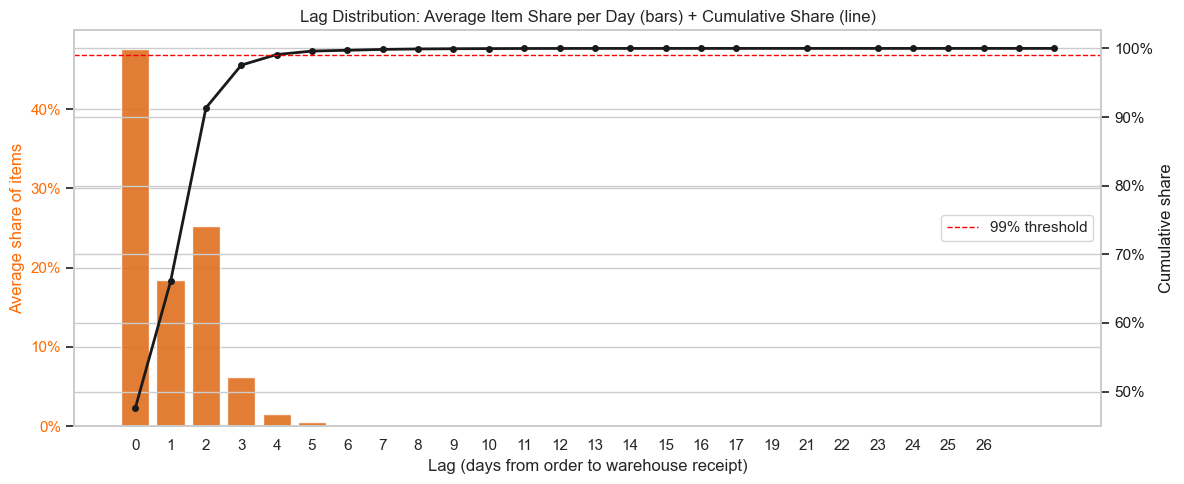

In [287]:
### Lag distribution visualisation (item-weighted)
lag_shares = (
    hist.pivot_table(index="date_order", columns="lag", values="share", aggfunc="sum", fill_value=0)
    .mean()
    .sort_index()
    .reset_index()
    .rename(columns={0: "avg_share"})
)
lag_shares.columns = ["lag", "avg_share"]
lag_shares["cumulative_share"] = lag_shares["avg_share"].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 5))

sns.barplot(data=lag_shares, x="lag", y="avg_share", ax=ax1, color="#FF6900", alpha=0.9)
ax1.set_xlabel("Lag (days from order to warehouse receipt)")
ax1.set_ylabel("Average share of items", color="#FF6900")
ax1.tick_params(axis="y", labelcolor="#FF6900")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

ax2 = ax1.twinx()
ax2.plot(lag_shares["lag"], lag_shares["cumulative_share"], color="#1A1A1A", linewidth=2, marker="o", markersize=4)
ax2.axhline(0.99, color="red", linestyle="--", linewidth=1, label="99% threshold")
ax2.set_ylabel("Cumulative share", color="#1A1A1A")
ax2.tick_params(axis="y", labelcolor="#1A1A1A")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.legend(loc="center right")

plt.title("Lag Distribution: Average Item Share per Day (bars) + Cumulative Share (line)")
plt.tight_layout()
plt.show()

### 3.6 Forecasted Items by Day of Week

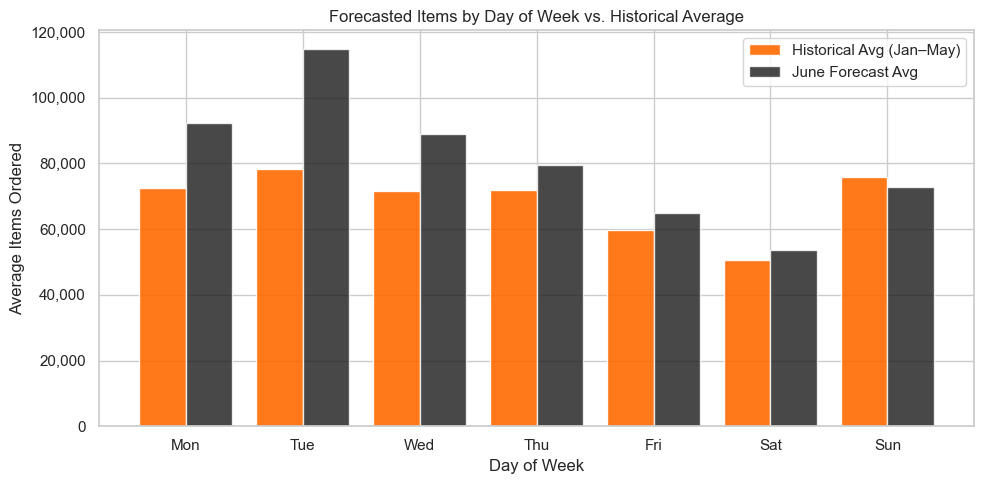

In [288]:
# Average daily orders by day of week — historical (input_1)
hist_dow = (
    hist.groupby(["date_order", "day_of_week_order"])["items"]
    .sum()
    .reset_index()
    .groupby("day_of_week_order")["items"]
    .mean()
    .reset_index()
    .rename(columns={"items": "hist_avg"})
)

# Average daily forecasted items by day of week — June forecast (input_2)
fc_dow = (
    fc.groupby("day_of_week_order")["Forecated_items"]
    .mean()
    .reset_index()
    .rename(columns={"Forecated_items": "fc_avg"})
)

# Merge
dow_compare = hist_dow.merge(fc_dow, on="day_of_week_order")
day_labels = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
dow_compare["day_label"] = dow_compare["day_of_week_order"].map(day_labels)

# Plot
x = np.arange(len(dow_compare))
width = 0.4

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, dow_compare["hist_avg"], width, label="Historical Avg (Jan–May)", color="#FF6900", alpha=0.9)
ax.bar(x + width/2, dow_compare["fc_avg"], width, label="June Forecast Avg", color="#1A1A1A", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(dow_compare["day_label"])
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Items Ordered")
ax.set_title("Forecasted Items by Day of Week vs. Historical Average")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax.legend()

plt.tight_layout()
plt.show()

**Observations:**
- **Day-of-week shape is well preserved** — both historical and June forecast follow the same pattern (Mon–Thu highest, Fri drops, Sat lowest, Sun recovers), validating our day-of-week segmented lag distribution.
- **June forecast is uniformly ~20–30% higher on weekdays** — reflects the overall higher demand forecast for June, not a structural shift in the day-of-week pattern. Consistent with the monthly trendline.
- **Sunday slightly below history** (~73k forecast vs ~76k historical) — small deviation, within normal variation.
- **Saturday closely aligned** — both at ~51–54k, the most consistent day between history and forecast.
- **Modelling implication:** the day-of-week profile of the June forecast is consistent with history. The day-of-week segmented lag distribution is well-calibrated for the forecast.

### 3.8 May Spillover Quantification

In [291]:
# May spillover: items from May orders received in June (directly from input_1)
spillover = hist[hist["date_wh_receive"].dt.month == 6].copy()

may_orders_total = hist[hist["date_order"].dt.month == 5]["items"].sum()
spillover_total = spillover["items"].sum()

print("=== May Spillover: Summary ===")
print(f"Total spillover items:           {spillover_total:>12,.0f}")
print(f"Total May ordered items:         {may_orders_total:>12,.0f}")
print(f"Spillover as % of May orders:    {spillover_total / may_orders_total * 100:>11.1f}%")
print(f"Receipt date range:              {spillover['date_wh_receive'].min().date()} → {spillover['date_wh_receive'].max().date()}")
print(f"Unique contributing order dates: {spillover['date_order'].nunique()}")

print("\nDaily spillover breakdown:")
daily_spill = spillover.groupby("date_wh_receive")["items"].sum().reset_index()
daily_spill.columns = ["receipt_date", "spillover_items"]
display(daily_spill.assign(
    pct_of_total=lambda d: d["spillover_items"] / spillover_total * 100
).style.format({"spillover_items": "{:,.0f}", "pct_of_total": "{:.1f}%"}))

=== May Spillover: Summary ===
Total spillover items:                 76,058
Total May ordered items:            2,240,077
Spillover as % of May orders:            3.4%
Receipt date range:              2022-06-01 → 2022-06-11
Unique contributing order dates: 15

Daily spillover breakdown:


,receipt_date,spillover_items,pct_of_total
0,2022-06-01 00:00:00,"51,835",68.2%
1,2022-06-02 00:00:00,"20,650",27.2%
2,2022-06-03 00:00:00,"2,626",3.5%
3,2022-06-04 00:00:00,173,0.2%
4,2022-06-05 00:00:00,33,0.0%
5,2022-06-06 00:00:00,41,0.1%
6,2022-06-07 00:00:00,342,0.4%
7,2022-06-08 00:00:00,209,0.3%
8,2022-06-09 00:00:00,82,0.1%
9,2022-06-10 00:00:00,57,0.1%


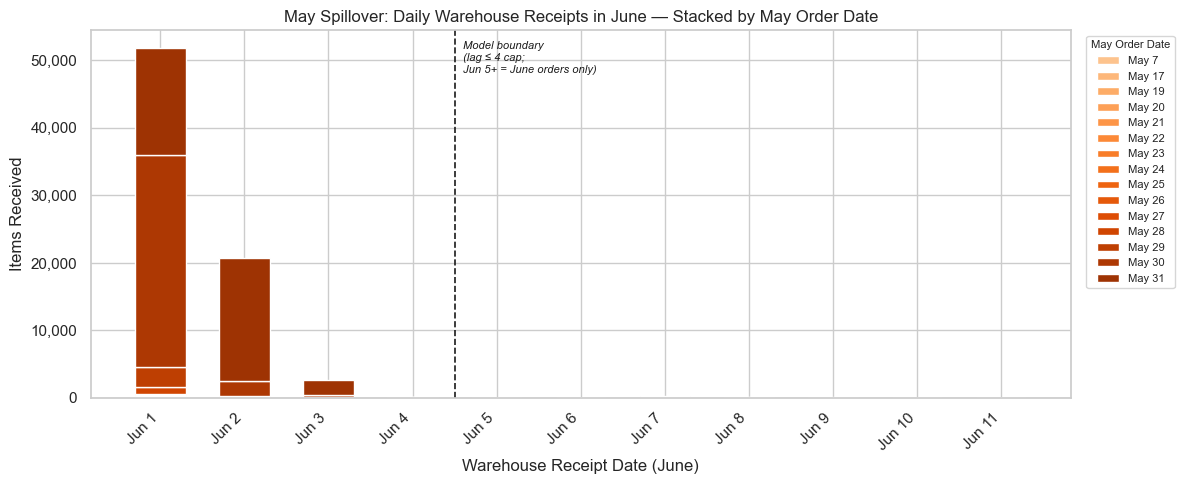

In [292]:
# Stacked bar chart: daily spillover by contributing May order date
spill_by_order = (
    spillover.groupby(["date_wh_receive", "date_order"])["items"]
    .sum()
    .reset_index()
)
spill_pivot = (
    spill_by_order
    .pivot_table(index="date_wh_receive", columns="date_order", values="items", fill_value=0)
    .sort_index()
)
spill_pivot.columns = [c.strftime("%b %-d") for c in spill_pivot.columns]

# Orange gradient: lighter for earlier order dates, darker for more recent
n_cols = len(spill_pivot.columns)
colors = [plt.cm.Oranges(0.3 + 0.6 * i / max(n_cols - 1, 1)) for i in range(n_cols)]

fig, ax = plt.subplots(figsize=(12, 5))

bottom = np.zeros(len(spill_pivot))
x = np.arange(len(spill_pivot))
for col, color in zip(spill_pivot.columns, colors):
    ax.bar(x, spill_pivot[col], bottom=bottom, color=color, label=col, width=0.6)
    bottom += spill_pivot[col].values

# Model boundary: May 31 + lag 4 = Jun 4 (last spillover day per our lag cap)
# Jun 5 onwards: only June orders contribute in the model
model_boundary_date = pd.Timestamp("2022-06-04")
if model_boundary_date in spill_pivot.index:
    boundary_x = list(spill_pivot.index).index(model_boundary_date)
    ax.axvline(x=boundary_x + 0.5, color="#1A1A1A", linestyle="--", linewidth=1.2)
    ymax = ax.get_ylim()[1]
    ax.text(boundary_x + 0.6, ymax * 0.97,
            "Model boundary\n(lag ≤ 4 cap;\nJun 5+ = June orders only)",
            fontsize=8, color="#1A1A1A", style="italic", va="top")

ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%b %-d") for d in spill_pivot.index], rotation=45, ha="right")
ax.set_xlabel("Warehouse Receipt Date (June)")
ax.set_ylabel("Items Received")
ax.set_title("May Spillover: Daily Warehouse Receipts in June — Stacked by May Order Date")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax.legend(title="May Order Date", bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()

**Observations:**
- **Total spillover: 76,058 items — 3.4% of May orders.** Small in relative terms but meaningful for the first 1–3 days of June.
- **Jun 1–3 account for ~99% of spillover:** Jun 1 alone carries 68.2% (51,835 items), Jun 2 adds 27.2% (20,650), and Jun 3 contributes 3.5% (2,626). The tail-off is sharp and consistent with the lag distribution.
- **Jun 4: 173 items (0.2%)** — negligible at daily receipt scale. Included in the model for completeness.
- **Jun 5–11: long-tail trickles totalling ~774 items across 7 days (~1% of spillover)** — these are lag > 4 arrivals excluded by the model cap. Their omission introduces no meaningful error.
- **15 contributing May order dates** — visible in the legend from May 7 onwards, but earlier dates contribute only trace amounts. The bulk of spillover volume comes from May 29–31 (darkest bars).
- **Model boundary confirmed at Jun 4:** from Jun 5 onwards, only June orders contribute to warehouse receipts. The spillover values for Jun 1–4 are known exact quantities from input_1 — no estimation needed for these dates in Section 4.

## 4. Forecast Generation

### 4.1 Build Lag Distribution (Jan–Apr Train Set)

Compute the day-of-week segmented lag distribution from Jan–Apr historical data only, capped at lag ≤ 4 days and normalised to sum to 1.0 per day-of-week. This is the train set — May is held out for validation.

In [294]:
# Define train set: Jan–Apr orders only (May held out for validation)
hist_train = hist[hist["date_order"].dt.month <= 4].copy()

print("=== Train Set: Jan–Apr Orders ===")
print(f"Rows:               {len(hist_train):>8,}")
print(f"Unique order dates: {hist_train['date_order'].nunique():>8,}")
print(f"Date range:         {hist_train['date_order'].min().date()} → {hist_train['date_order'].max().date()}")
print(f"Total items:        {hist_train['items'].sum():>8,.0f}")

print("\nOrder dates per day of week:")
dow_counts = (
    hist_train.groupby("day_of_week_order")["date_order"]
    .nunique()
    .reset_index()
)
dow_counts["day_name"] = dow_counts["day_of_week_order"].map(
    {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
)
dow_counts.columns = ["day_of_week", "unique_order_dates", "day_name"]
display(dow_counts[["day_name", "day_of_week", "unique_order_dates"]])

=== Train Set: Jan–Apr Orders ===
Rows:                  1,410
Unique order dates:      120
Date range:         2022-01-01 → 2022-04-30
Total items:        8,125,064

Order dates per day of week:


,day_name,day_of_week,unique_order_dates
0,Mon,1,17
1,Tue,2,17
2,Wed,3,17
3,Thu,4,17
4,Fri,5,17
5,Sat,6,18
6,Sun,7,17


#### Compute lag distribution: average item-weighted share per (day_of_week_order, lag)

Two approaches compared — **mean-of-shares** vs **aggregate-shares**.

**Mean-of-shares** computes each order date's lag fractions first, then averages them across dates. Every order date gets equal vote regardless of how many items it had.

**Aggregate-shares** pools all items across order dates, then computes fractions from the totals. Each item gets equal weight — high-volume days naturally have more influence.

**Example: 2 Mondays**

| Monday | Total items | Arrived lag 0 | Arrived lag 1 |
|--------|-------------|---------------|---------------|
| Mon A  | 100         | 80 (80%)      | 20 (20%)      |
| Mon B  | 1,000       | 500 (50%)     | 500 (50%)     |

- **Mean-of-shares** → lag 0 = (80% + 50%) / 2 = **65%**, lag 1 = **35%**
- **Aggregate-shares** → lag 0 = 580 / 1,100 = **52.7%**, lag 1 = 520 / 1,100 = **47.3%**

Mon A (low volume, very same-day heavy) pulls the mean-of-shares estimate upward — even though Mon B has 10× more items and is a better signal of typical behaviour. Aggregate-shares correctly down-weights Mon A by letting the volume speak.

In [307]:
hist_train_capped = hist_train[hist_train["lag"] <= 4].copy()

In [308]:
# Approach A: mean of per-date item shares (each order date weighted equally)
lag_dist_mean = (
    hist_train_capped
    .groupby(["day_of_week_order", "lag"])["share"]
    .mean()
)
lag_dist_mean.reset_index().head()

,day_of_week_order,lag,share
0,1,0,0.4
1,1,1,0.2
2,1,2,0.3
3,1,3,0.0
4,1,4,0.0


In [310]:
# Approach B: aggregate share (each item weighted equally across all dates)
# date_order is already the lowest granularity — grouping directly by day_of_week_order is equivalent
total_items_by_dow = hist_train_capped.groupby("day_of_week_order")["items"].sum()

lag_dist_agg = (
    hist_train_capped
    .groupby(["day_of_week_order", "lag"])["items"]
    .sum()
    .div(total_items_by_dow, level="day_of_week_order")
)
lag_dist_agg.reset_index().head()

,day_of_week_order,lag,items
0,1,0,0.4
1,1,1,0.2
2,1,2,0.3
3,1,3,0.0
4,1,4,0.0


In [303]:
# Compare the two approaches
comparison = pd.DataFrame({
    "mean_of_shares": lag_dist_mean,
    "aggregate_shares": lag_dist_agg,
}).reset_index()
comparison["diff"] = (comparison["mean_of_shares"] - comparison["aggregate_shares"]).abs()

print("=== Approach Comparison: Mean-of-Shares vs Aggregate-Shares ===")
print(f"Max absolute difference across all (dow, lag): {comparison['diff'].max():.4f}")
print(f"Mean absolute difference:                      {comparison['diff'].mean():.4f}")
display(comparison.style.format({
    "mean_of_shares": "{:.3f}",
    "aggregate_shares": "{:.3f}",
    "diff": "{:.4f}"
}))

=== Approach Comparison: Mean-of-Shares vs Aggregate-Shares ===
Max absolute difference across all (dow, lag): 0.0212
Mean absolute difference:                      0.0063


,day_of_week_order,lag,mean_of_shares,aggregate_shares,diff
0,1,0,0.426,0.410,0.0161
1,1,1,0.231,0.238,0.0067
2,1,2,0.327,0.341,0.0136
3,1,3,0.010,0.010,0.0002
4,1,4,0.002,0.002,0.0001
5,2,0,0.499,0.478,0.0212
6,2,1,0.239,0.254,0.0151
7,2,2,0.248,0.257,0.0098
8,2,3,0.008,0.008,0.0004
9,2,4,0.002,0.002,0.0001


In [304]:
# Show where the largest differences occur
day_labels = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
comparison["day_name"] = comparison["day_of_week_order"].map(day_labels)
top_diffs = comparison.nlargest(5, "diff")[["day_name", "lag", "mean_of_shares", "aggregate_shares", "diff"]]
print("=== Top 5 (day_of_week, lag) differences ===")
display(top_diffs.style.format({
    "mean_of_shares": "{:.3f}",
    "aggregate_shares": "{:.3f}",
    "diff": "{:.4f}"
}))

=== Top 5 (day_of_week, lag) differences ===


,day_name,lag,mean_of_shares,aggregate_shares,diff
5,Tue,0,0.499,0.478,0.0212
32,Sun,2,0.328,0.349,0.0203
27,Sat,2,0.381,0.397,0.0161
0,Mon,0,0.426,0.410,0.0161
6,Tue,1,0.239,0.254,0.0151


The largest difference (2.12pp) is on **Tue lag 0** — mean-of-shares overstates same-day Tuesday arrivals by 2.12pp relative to aggregate-shares. The remaining top-5 differences (1.51–2.03pp) fall on lag 0–2 for Mon, Sun, and Sat — the lags where most items arrive.

At June forecast scale (~2.43M items), 2.12pp on Tuesday lag 0 alone translates to ~7,000–8,000 items misallocated on a single day — a meaningful staffing signal.

Since we are distributing item volumes, each item should count equally — not each calendar date. **Aggregate-shares is the correct choice**; the results confirm the difference is large enough to matter.

In [ ]:
# Normalise chosen distribution so each day-of-week sums to exactly 1.0
# Rename to "share" so apply_lag_model can reference fc_lag["share"] consistently
lag_dist_norm = (lag_dist_agg / lag_dist_agg.groupby("day_of_week_order").sum()).rename("share")

print("=== Normalised Lag Distribution (Aggregate, Jan–Apr Train Set) ===")
lag_dist_table = (
    lag_dist_norm
    .reset_index()
    .pivot(index="day_of_week_order", columns="lag", values="share")
    .fillna(0)
)
lag_dist_table.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
lag_dist_table.columns = [f"lag_{c}" for c in lag_dist_table.columns]

display(lag_dist_table.style.format("{:.1%}"))

print("\nRow sums (should all be 1.0):")
print(lag_dist_table.sum(axis=1).to_frame("sum").T)

**Observations:**
- **Mon–Thu** follow a consistent pattern: lag 0 dominates (41–50%), with lags 1 and 2 sharing the remainder and a negligible tail beyond lag 3.
- **Monday** is the only weekday where lag 2 (34.1%) exceeds lag 1 (23.8%) — likely absorbing spillover from Friday/weekend orders of the prior week.
- **Friday** is the most distinctive profile: lag 2 collapses to 0.4% with a spike at lag 3 (22.6%) and lag 4 (5.6%). Friday orders skip Saturday warehouse processing and arrive predominantly on Monday–Tuesday.
- **Saturday** has near-zero lag 1 (1.8%) and a large lag 2 peak (39.7%) — most Saturday orders arrive on Monday.
- **Sunday** shows a split between lag 0 (46.7%) and lag 2 (34.9%), with a depressed lag 1 (15.8%) — consistent with reduced Sunday warehouse operations seen in section 3.3.
- These patterns are consistent with the heatmap in section 3.3, now normalised and capped at lag ≤ 4 days for application to the June forecast.

### 4.2 Validate on May

Apply the Jan–Apr lag distribution to actual May orders plus April spillover. Compare predicted vs actual May warehouse receipts to assess lag model accuracy before applying to June.

In [317]:
# May orders — aggregate input_1 May rows to daily totals, mirroring fc structure
may_orders = (
    hist[hist["date_order"].dt.month == 5]
    .groupby(["date_order", "day_of_week_order"])["items"]
    .sum()
    .reset_index()
    .rename(columns={"items": "Forecasted_items"})
)
may_orders.head()

,date_order,day_of_week_order,Forecasted_items
0,2022-05-01,7,104200
1,2022-05-02,1,105356
2,2022-05-03,2,102407
3,2022-05-04,3,83761
4,2022-05-05,4,59848


In [318]:
# April spillover into May — exact known receipts from input_1
april_spillover = (
    hist[
        (hist["date_order"].dt.month == 4) &
        (hist["date_wh_receive"].dt.month == 5)
    ]
    .groupby("date_wh_receive")["items"]
    .sum()
)
april_spillover.head()

date_wh_receive
2022-05-01     5083
2022-05-02    30096
2022-05-03    35616
2022-05-04     1949
2022-05-05     1608
Name: items, dtype: int64

In [321]:
# Actual May receipts — ground truth
actual_may = (
    hist[hist["date_wh_receive"].dt.month == 5]
    .groupby("date_wh_receive")["items"]
    .sum()
)
actual_may.head()

date_wh_receive
2022-05-01     44988
2022-05-02     89161
2022-05-03    133616
2022-05-04     93004
2022-05-05    108842
Name: items, dtype: int64

In [322]:
print(f"May order dates:        {len(may_orders)}")
print(f"April spillover dates:  {len(april_spillover)} | total items: {april_spillover.sum():,.0f}")
print(f"Actual May receipt days:{len(actual_may)}")

May order dates:        31
April spillover dates:  15 | total items: 75,050
Actual May receipt days:31


In [323]:
def apply_lag_model(orders_df, lag_dist, spillover_series, target_month):
    """
    Applies a day-of-week segmented lag distribution to daily order volumes
    to produce predicted warehouse receipt volumes for a target month.

    Args:
        orders_df        : DataFrame with columns [date_order, day_of_week_order, Forecasted_items]
                           -- one row per order date (daily totals)
        lag_dist         : Series indexed by (day_of_week_order, lag) with values named "share"
                           -- normalised lag distribution summing to 1.0 per day-of-week
        spillover_series : Series indexed by date -- known prior-month receipts arriving in target_month
        target_month     : int -- calendar month to filter receipt dates (e.g. 5 for May)

    Returns:
        Series indexed by receipt_date -- predicted daily warehouse receipt volumes for target_month,
        including spillover from the prior month
    """
    fc_lag = orders_df.merge(
        lag_dist.reset_index(), on="day_of_week_order"
    )
    fc_lag["receipt_date"] = fc_lag["date_order"] + pd.to_timedelta(fc_lag["lag"], unit="D")
    fc_lag["receipt_items"] = fc_lag["Forecasted_items"] * fc_lag["share"]

    receipts = (
        fc_lag[fc_lag["receipt_date"].dt.month == target_month]
        .groupby("receipt_date")["receipt_items"]
        .sum()
    )
    return receipts.add(spillover_series, fill_value=0)

predicted_may = apply_lag_model(may_orders, lag_dist_norm, april_spillover, target_month=5)
print(f"Predicted May receipt days: {len(predicted_may)}")
print(f"Predicted May total items:  {predicted_may.sum():,.0f}")
print(f"Actual May total items:     {actual_may.sum():,.0f}")

Predicted May receipt days: 31
Predicted May total items:  2,249,715
Actual May total items:     2,239,069


In [324]:
# Validation metrics — predicted vs actual daily May receipts
comparison = pd.DataFrame({
    "actual": actual_may,
    "predicted": predicted_may
}).dropna()

mae  = (comparison["actual"] - comparison["predicted"]).abs().mean()
mape = ((comparison["actual"] - comparison["predicted"]).abs() / comparison["actual"]).mean() * 100
bias = (comparison["predicted"] - comparison["actual"]).mean()
rmse = ((comparison["actual"] - comparison["predicted"]) ** 2).mean() ** 0.5

print("=== May Validation Metrics ===")
print(f"MAE:  {mae:>10,.0f} items  (mean absolute daily error)")
print(f"MAPE: {mape:>9.1f}%        (mean absolute % error)")
print(f"Bias: {bias:>10,.0f} items  (predicted − actual; + = over-forecast)")
print(f"RMSE: {rmse:>10,.0f} items  (penalises peak-day misses)")

=== May Validation Metrics ===
MAE:       7,862 items  (mean absolute daily error)
MAPE:      11.6%        (mean absolute % error)
Bias:        343 items  (predicted − actual; + = over-forecast)
RMSE:     10,720 items  (penalises peak-day misses)


**Observations:**
- **Monthly total accuracy is excellent:** predicted 2,249,715 vs actual 2,239,069 — only 0.5% over at the monthly level. The model captures the right overall volume.
- **Bias is negligible:** +343 items/day averages out to ~10,600 items over the full month — no meaningful systematic over or under-forecasting.
- **MAE and MAPE reflect timing error:** average daily receipts in May are ~72,200 items (2.24M / 31). MAE of 7,862 (~11% of daily average) is consistent with the 11.6% MAPE. This is the cost of items arriving a day earlier or later than predicted — acceptable for a statistical lag model.
- **RMSE/MAE ratio of 1.36 is healthy:** a ratio close to 1 means errors are evenly distributed across days. 1.36 indicates no extreme peak-day misses that would signal a structural model failure.
- **Caveat:** this validation tests lag distribution accuracy only. In June, forecast accuracy will additionally depend on whether input_2's order volumes are correct — a separate, uncontrollable source of error.

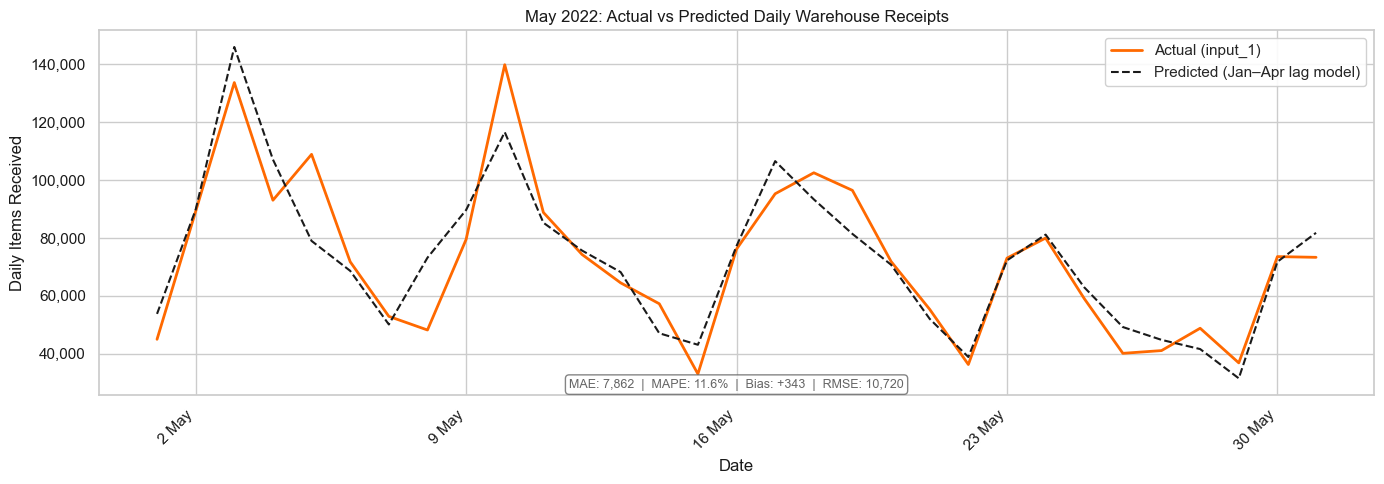

In [326]:
# Actual vs predicted daily receipts for May
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(comparison.index, comparison["actual"], color="#FF6900", linewidth=2, label="Actual (input_1)")
ax.plot(comparison.index, comparison["predicted"], color="#1A1A1A", linewidth=1.5,
        linestyle="--", label="Predicted (Jan–Apr lag model)")

ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%-d %b"))
plt.xticks(rotation=45, ha="right")

ax.set_xlabel("Date", color="#1A1A1A")
ax.set_ylabel("Daily Items Received", color="#1A1A1A")
ax.set_title("May 2022: Actual vs Predicted Daily Warehouse Receipts", color="#1A1A1A")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:,.0f}"))
ax.tick_params(colors="#1A1A1A")
ax.legend(framealpha=0.9)

metric_text = f"MAE: {mae:,.0f}  |  MAPE: {mape:.1f}%  |  Bias: {bias:+,.0f}  |  RMSE: {rmse:,.0f}"
ax.annotate(metric_text, xy=(0.5, 0.02), xycoords="axes fraction",
            ha="center", fontsize=9, color="#666666",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#666666", alpha=0.8))

plt.tight_layout()
plt.show()

### 4.3 Rebuild Lag Distribution (Full Jan–May)

Retrain the lag distribution using the complete Jan–May historical dataset. More data produces more reliable share estimates, particularly for weekend days which have fewer unique order dates per month.

In [328]:
# Rebuild lag distribution on full Jan–May history (all 151 unique order dates)
hist_capped = hist[hist["lag"] <= 4]
total_items_by_dow_full = hist_capped.groupby("day_of_week_order")["items"].sum()

lag_dist_full = (
    hist_capped
    .groupby(["day_of_week_order", "lag"])["items"]
    .sum()
    .div(total_items_by_dow_full, level="day_of_week_order")
)
lag_dist_full_norm = (lag_dist_full / lag_dist_full.groupby("day_of_week_order").sum()).rename("share")

print("=== Normalised Lag Distribution (Aggregate, Full Jan–May) ===")
lag_dist_full_table = (
    lag_dist_full_norm
    .reset_index()
    .pivot(index="day_of_week_order", columns="lag", values="share")
    .fillna(0)
)
lag_dist_full_table.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
lag_dist_full_table.columns = [f"lag_{c}" for c in lag_dist_full_table.columns]

display(lag_dist_full_table.style.format("{:.1%}"))

print("\nRow sums (should all be 1.0):")
print(lag_dist_full_table.sum(axis=1).to_frame("sum").T)

=== Normalised Lag Distribution (Aggregate, Full Jan–May) ===


,lag_0,lag_1,lag_2,lag_3,lag_4
Mon,41.2%,22.4%,33.6%,2.5%,0.3%
Tue,46.7%,24.7%,26.8%,1.6%,0.2%
Wed,48.9%,22.8%,25.1%,3.2%,0.0%
Thu,49.9%,26.1%,21.6%,0.3%,2.1%
Fri,52.5%,19.2%,0.4%,22.6%,5.4%
Sat,45.7%,3.3%,38.3%,10.8%,1.9%
Sun,43.3%,15.7%,36.9%,3.3%,0.7%



Row sums (should all be 1.0):
     Mon  Tue  Wed  Thu  Fri  Sat  Sun
sum  1.0  1.0  1.0  1.0  1.0  1.0  1.0


In [329]:
# Compare Jan–Apr vs Jan–May distributions to see how adding May shifts the profiles
diff_table = lag_dist_full_table - lag_dist_table

print("=== Difference: Jan–May minus Jan–Apr (pp) ===")
display(diff_table.style.format("{:+.1%}"
    ).background_gradient(cmap="RdYlGn", axis=None, vmin=-0.05, vmax=0.05))

print(f"\nMax absolute shift: {diff_table.abs().max().max():.1%}")
print(f"Mean absolute shift: {diff_table.abs().mean().mean():.1%}")

=== Difference: Jan–May minus Jan–Apr (pp) ===


,lag_0,lag_1,lag_2,lag_3,lag_4
Mon,+0.2%,-1.3%,-0.5%,+1.6%,+0.1%
Tue,-1.1%,-0.7%,+1.0%,+0.7%,+0.0%
Wed,+0.0%,-1.0%,+0.6%,+0.4%,+0.0%
Thu,+0.4%,-1.6%,+1.0%,+0.0%,+0.2%
Fri,+0.2%,+0.0%,-0.1%,+0.0%,-0.2%
Sat,+0.3%,+1.5%,-1.5%,-0.4%,+0.1%
Sun,-3.4%,-0.0%,+2.0%,+1.2%,+0.2%



Max absolute shift: 3.4%
Mean absolute shift: 0.7%


**Observations:**
- **Distribution is broadly stable** — most weekday shifts (Tue–Thu) are ≤ 1.1pp, and Friday is essentially unchanged. The Jan–Apr model was already well-calibrated.
- **Sunday has the largest shift:** lag 0 drops 3.4pp (46.7% → 43.3%) and lag 2 rises 2.0pp (34.9% → 36.9%). May Sundays show slightly less same-day processing and more lag-2 arrivals — likely reflecting operational variation in May or the additional 4–5 Sunday data points pulling the average.
- **Saturday lag 1** increases by 1.5pp (1.8% → 3.3%) — minor shift, structural pattern unchanged.
- **Monday lag 3** rises by 1.5pp (1.0% → 2.5%) — small increase in late-arriving Monday orders, within normal variation.
- **All structural patterns preserved:** Friday's lag-3 spike, Saturday's lag-2 peak, and Sunday's suppressed lag-1 are all intact. This is the distribution used for the June forecast.

### 4.4 Apply to June + Write Output

Apply the full Jan–May lag distribution to the June order forecast (input_2), add the known May spillover for Jun 1–4, and write the final daily receipt forecast to `data_output/expected_output.csv`.